# 06. Price regression ablation

Regression model for **Friday close** from daily OHLCV bars ending at Monday close.

**Ablation axes (additive ladder)**
- Window N (count of daily bars up to and including Monday): {6, 11}
- Tier: OHLCV -> +Technicals (stoch, RSI, OBV) -> +Market context (SPY, VIX)
- Model: RF, XGBoost, LightGBM, PyTorch LSTM

**Target**: raw `close_friday` (regression). Reported as both `price_r2` (high,
autocorrelation-dominated) and `return_r2` (honest weekly predictability, near
zero expected).

**Scope**: pooled across 35 HQ tickers. No per-ticker refit. No hyperparameter
tuning. Fixed hyperparameters throughout so the ablation story is about
feature groups, not tuning.

**Data**: everything from yfinance. Local caches in `data/daily_yf/` for the 35
tickers plus `SPY.csv` and `VIX.csv`. No Alpha Vantage.

**Split**: 80th-percentile Monday date (same convention as notebook 11).


In [1]:
import warnings
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import talib
import torch
import torch.nn as nn
import xgboost as xgb
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

from config import HIGH_QUALITY_TICKERS

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

DAILY_YF_DIR = Path("data/daily_yf")
LABELS_PATH = Path("output/03_weekly_strategy_labels/strategy_labels.parquet")
OUT_DIR = Path("output/06_price_regression_ablation")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
WINDOWS = [6, 11]
MAX_WINDOW = max(WINDOWS)
SPLIT_DATE = pd.Timestamp("2025-01-01")  # train: 2020-2024, test: 2025-2026
TECH_WARMUP = 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"device: {device}")
print(f"HQ tickers: {len(HIGH_QUALITY_TICKERS)}")


device: cuda
HQ tickers: 35


## 1. Weekly frame

Pull unique `(ticker, monday_date, friday_date)` keys from `strategy_labels`.
`monday_close` and `friday_close` in strategy_labels are raw (non-split-adjusted)
prices, so we **re-fetch** both from `daily_yf/` which is split-adjusted and
consistent with the feature source. Without this, GOOGL pre-2022 is in
the $1000-3000 range while post-2022 features are in $100-300 - the model
sees an artificial discontinuity.

In [2]:
labels = pd.read_parquet(LABELS_PATH)
weekly_keys = (
    labels[["ticker", "monday_date", "friday_date"]]
    .drop_duplicates()
    .sort_values(["monday_date", "ticker"])
    .reset_index(drop=True)
)
weekly_keys["monday_date"] = pd.to_datetime(weekly_keys["monday_date"])
weekly_keys["friday_date"] = pd.to_datetime(weekly_keys["friday_date"])

print(f"weekly keys from strategy_labels: {len(weekly_keys):,} rows")
print(f"  tickers : {weekly_keys['ticker'].nunique()}")
print(f"  mondays : {weekly_keys['monday_date'].nunique()}")
print(f"  range   : {weekly_keys['monday_date'].min().date()} -> {weekly_keys['monday_date'].max().date()}")


weekly keys from strategy_labels: 6,902 rows
  tickers : 35
  mondays : 280
  range   : 2020-01-06 -> 2026-03-23


## 2. Load daily OHLCV + SPY + VIX

All from `data/daily_yf/` (cached yfinance pulls).

In [3]:
def load_daily(ticker: str) -> pd.DataFrame | None:
    p = DAILY_YF_DIR / f"{ticker}.csv"
    if not p.exists():
        return None
    df = pd.read_csv(p, parse_dates=["date"]).set_index("date").sort_index()
    if df["adjusted_close"].isna().all():
        df["adjusted_close"] = df["close"]
    return df


daily = {t: load_daily(t) for t in HIGH_QUALITY_TICKERS}
daily = {k: v for k, v in daily.items() if v is not None}
spy = load_daily("SPY")
vix = load_daily("VIX")

print(f"loaded {len(daily)} HQ tickers")
print(f"SPY: {spy.index.min().date()} -> {spy.index.max().date()} ({len(spy):,} rows)")
print(f"VIX: {vix.index.min().date()} -> {vix.index.max().date()} ({len(vix):,} rows)")


loaded 35 HQ tickers
SPY: 1993-01-29 -> 2026-04-20 (8,362 rows)
VIX: 1990-01-02 -> 2026-04-21 (9,142 rows)


## 3. Technical indicators + market context features

Compute on the full daily series first so each indicator has the lookback it
needs. Lag stacking happens after.

In [4]:
def compute_rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0).rolling(period).mean()
    loss = (-delta.clip(upper=0)).rolling(period).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - 100 / (1 + rs)


def compute_stoch(high: pd.Series, low: pd.Series, close: pd.Series,
                  fastk_period: int = 14, slowk_period: int = 3,
                  slowd_period: int = 3) -> tuple[pd.Series, pd.Series]:
    # TA-Lib slow stochastic: Fast %K smoothed by slowk_period SMA, then slowd_period SMA on top
    slowk, slowd = talib.STOCH(
        high.astype(float).values,
        low.astype(float).values,
        close.astype(float).values,
        fastk_period=fastk_period,
        slowk_period=slowk_period,
        slowk_matype=0,
        slowd_period=slowd_period,
        slowd_matype=0,
    )
    return pd.Series(slowk, index=close.index), pd.Series(slowd, index=close.index)


def compute_obv(close: pd.Series, volume: pd.Series) -> pd.Series:
    sign = np.sign(close.diff()).fillna(0)
    return (sign * volume).cumsum()


def compute_daily_features(df: pd.DataFrame) -> pd.DataFrame:
    close = df["adjusted_close"]
    high = df["high"]
    low = df["low"]
    vol = df["volume"]
    stoch_k, stoch_d = compute_stoch(high, low, close)
    return pd.DataFrame(
        {
            "open": df["open"],
            "high": df["high"],
            "low": df["low"],
            "close": close,
            "volume": vol,
            "stoch_k": stoch_k,
            "stoch_d": stoch_d,
            "rsi_14": compute_rsi(close),
            "obv": compute_obv(close, vol),
        },
        index=df.index,
    )


daily_feat = {t: compute_daily_features(df) for t, df in daily.items()}

spy_close = spy["adjusted_close"]
spy_ret = spy_close.pct_change()
mkt = pd.DataFrame(
    {
        "spy_close": spy_close,
        "spy_ret_1d": spy_ret,
        "spy_vol_20d": spy_ret.rolling(20).std() * np.sqrt(252),
        "vix_close": vix["adjusted_close"].reindex(spy_close.index, method="ffill"),
    },
    index=spy_close.index,
)

print(f"daily features per ticker: {list(daily_feat['AAPL'].columns)}")
print(f"market context: {list(mkt.columns)}")


daily features per ticker: ['open', 'high', 'low', 'close', 'volume', 'stoch_k', 'stoch_d', 'rsi_14', 'obv']
market context: ['spy_close', 'spy_ret_1d', 'spy_vol_20d', 'vix_close']


## 4. Lag-stacked wide feature frame

For each `(ticker, monday_date)`, take the last `MAX_WINDOW = 11` daily bars
ending at `monday_date` (inclusive). Rename into columns
`{channel}_lag{k}` where `k=1` is the Monday bar and `k=11` is the oldest bar.

Rows missing sufficient history (technical warmup) are dropped.

In [5]:
OHLCV_CH = ["open", "high", "low", "close", "volume"]
TECH_CH = ["stoch_k", "stoch_d", "rsi_14", "obv"]
MKT_CH = ["spy_close", "spy_ret_1d", "spy_vol_20d", "vix_close"]
ALL_CH = OHLCV_CH + TECH_CH + MKT_CH

rows: list[dict] = []
skipped = 0
for row in weekly_keys.itertuples(index=False):
    tdf = daily_feat.get(row.ticker)
    if tdf is None:
        skipped += 1
        continue
    raw_daily = daily.get(row.ticker)
    if raw_daily is None:
        skipped += 1
        continue
    # Pull split-adjusted close from daily_yf for the Monday and Friday dates.
    if row.monday_date not in raw_daily.index or row.friday_date not in raw_daily.index:
        skipped += 1
        continue
    monday_close = float(raw_daily.loc[row.monday_date, "close"])
    friday_close = float(raw_daily.loc[row.friday_date, "close"])
    daily_up_to = tdf.loc[tdf.index <= row.monday_date]
    mkt_up_to = mkt.loc[mkt.index <= row.monday_date]
    if len(daily_up_to) < MAX_WINDOW + TECH_WARMUP:
        skipped += 1
        continue
    recent = daily_up_to.iloc[-MAX_WINDOW:]
    mkt_recent = mkt_up_to.reindex(recent.index, method="ffill")
    if recent.isna().any().any() or mkt_recent.isna().any().any():
        skipped += 1
        continue
    record = {
        "ticker": row.ticker,
        "monday_date": row.monday_date,
        "friday_date": row.friday_date,
        "monday_close": monday_close,
        "friday_close": friday_close,
    }
    # lag 1 = Monday (most recent), lag MAX_WINDOW = oldest
    for lag in range(1, MAX_WINDOW + 1):
        bar = recent.iloc[-lag]
        mbar = mkt_recent.iloc[-lag]
        for ch in OHLCV_CH + TECH_CH:
            record[f"{ch}_lag{lag}"] = bar[ch]
        for ch in MKT_CH:
            record[f"{ch}_lag{lag}"] = mbar[ch]
    rows.append(record)

feat_df = pd.DataFrame(rows).dropna().reset_index(drop=True)
print(f"built feature frame: {len(feat_df):,} rows x {len(feat_df.columns)} cols (skipped {skipped})")
print(f"  tickers : {feat_df['ticker'].nunique()}")
print(f"  mondays : {feat_df['monday_date'].nunique()}")


built feature frame: 6,882 rows x 148 cols (skipped 20)
  tickers : 35
  mondays : 280


## 5. Train/test split + per-ticker z-score

Split at **2025-01-01**: train = 2020-2024, test = 2025-2026. Scale features
and target per ticker, fit on train only, store scalers to invert predictions
back to raw dollars.

In [6]:
feat_df = feat_df.sort_values(["monday_date", "ticker"]).reset_index(drop=True)
split_date = SPLIT_DATE
train_df = feat_df[feat_df["monday_date"] < split_date].reset_index(drop=True)
test_df = feat_df[feat_df["monday_date"] >= split_date].reset_index(drop=True)
print(f"split at {split_date.date()}")
print(f"  train : {len(train_df):,} rows")
print(f"  test  : {len(test_df):,} rows")

META_COLS = ["ticker", "monday_date", "friday_date", "monday_close", "friday_close"]
FEAT_COLS_ALL = [c for c in feat_df.columns if c not in META_COLS]

scalers: dict[str, dict] = {}
for ticker in feat_df["ticker"].unique():
    tr = train_df[train_df["ticker"] == ticker]
    if len(tr) == 0:
        continue
    feat_mean = tr[FEAT_COLS_ALL].mean()
    feat_std = tr[FEAT_COLS_ALL].std().replace(0, 1.0).fillna(1.0)
    close_std_raw = float(tr["friday_close"].std())
    close_std = close_std_raw if (close_std_raw > 1e-6 and not np.isnan(close_std_raw)) else 1.0
    scalers[ticker] = {
        "feat_mean": feat_mean,
        "feat_std": feat_std,
        "close_mean": float(tr["friday_close"].mean()),
        "close_std": close_std,
    }

def scale_features(df: pd.DataFrame) -> pd.DataFrame:
    scaled = df[FEAT_COLS_ALL].astype(float).copy()
    for ticker, sc in scalers.items():
        m = df["ticker"].values == ticker
        if not m.any():
            continue
        scaled.loc[m, FEAT_COLS_ALL] = (
            (scaled.loc[m, FEAT_COLS_ALL].values - sc["feat_mean"].values) / sc["feat_std"].values
        )
    return scaled


def scale_target(df: pd.DataFrame) -> np.ndarray:
    y = df["friday_close"].values.astype(np.float64).copy()
    for ticker, sc in scalers.items():
        m = (df["ticker"].values == ticker)
        if not m.any():
            continue
        y[m] = (y[m] - sc["close_mean"]) / sc["close_std"]
    return y


def unscale_target(y: np.ndarray, df: pd.DataFrame) -> np.ndarray:
    out = y.astype(np.float64).copy()
    for ticker, sc in scalers.items():
        m = (df["ticker"].values == ticker)
        if not m.any():
            continue
        out[m] = out[m] * sc["close_std"] + sc["close_mean"]
    return out


X_train_scaled = scale_features(train_df)
X_test_scaled = scale_features(test_df)
y_train_scaled = scale_target(train_df)
y_test_scaled = scale_target(test_df)
print(f"scaled: X_train={X_train_scaled.shape}, X_test={X_test_scaled.shape}")


split at 2025-01-01
  train : 5,002 rows
  test  : 1,880 rows
scaled: X_train=(5002, 143), X_test=(1880, 143)


## 6. Metric helpers

- `price_r2`: R² on raw `close_friday`. Looks high because weekly prices are autocorrelated.
- `return_r2`: R² on the implied return `(pred / monday_close) - 1`. Honest signal check.
- `price_mae`: per-ticker MAE in dollars, then averaged (prevents NVDA dominating).
- `hit_rate`: sign accuracy of the implied return.
- `spearman_weekly`: cross-sectional rank correlation per Monday, averaged across test Mondays.

In [7]:
def evaluate(
    pred_close: np.ndarray,
    actual_close: np.ndarray,
    monday_close: np.ndarray,
    monday_date: np.ndarray,
    ticker: np.ndarray,
) -> dict:
    price_r2 = r2_score(actual_close, pred_close)
    actual_ret = actual_close / monday_close - 1.0
    pred_ret = pred_close / monday_close - 1.0
    return_r2 = r2_score(actual_ret, pred_ret)
    per_ticker_mae = []
    for t in np.unique(ticker):
        mask = ticker == t
        if mask.sum() > 0:
            per_ticker_mae.append(mean_absolute_error(actual_close[mask], pred_close[mask]))
    price_mae = float(np.mean(per_ticker_mae))
    hit = float((np.sign(actual_ret) == np.sign(pred_ret)).mean())
    weekly_spearmans = []
    for d in np.unique(monday_date):
        m = monday_date == d
        if m.sum() >= 3:
            r, _ = spearmanr(pred_ret[m], actual_ret[m])
            if not np.isnan(r):
                weekly_spearmans.append(float(r))
    spearman_weekly = float(np.mean(weekly_spearmans)) if weekly_spearmans else float("nan")
    return {
        "price_r2": price_r2,
        "return_r2": return_r2,
        "price_mae": price_mae,
        "hit_rate": hit,
        "spearman_weekly": spearman_weekly,
    }


def tier_channels(tier: str) -> list[str]:
    if tier == "OHLCV":
        return OHLCV_CH
    if tier == "+Tech":
        return OHLCV_CH + TECH_CH
    if tier == "+MktCtx":
        return OHLCV_CH + TECH_CH + MKT_CH
    raise ValueError(tier)


def tier_columns(tier: str, window: int) -> list[str]:
    chs = tier_channels(tier)
    return [f"{ch}_lag{k}" for k in range(1, window + 1) for ch in chs]


## 7. Tabular model grid (RF / XGB / LGB)

2 windows × 3 tiers × 3 models = 18 fits. All CPU. No tuning - fixed
hyperparameters.

In [8]:
TIER_ORDER = ["OHLCV", "+Tech", "+MktCtx"]
TABULAR_MODELS = ["RF", "XGB", "LGB"]


def make_tabular(name: str):
    if name == "RF":
        return RandomForestRegressor(
            n_estimators=300, max_depth=10, n_jobs=-1, random_state=SEED
        )
    if name == "XGB":
        return xgb.XGBRegressor(
            n_estimators=400, max_depth=6, learning_rate=0.05,
            tree_method="hist", random_state=SEED, verbosity=0,
            n_jobs=-1,
        )
    if name == "LGB":
        return lgb.LGBMRegressor(
            n_estimators=400, max_depth=6, learning_rate=0.05,
            reg_lambda=0.1, random_state=SEED, verbose=-1, n_jobs=-1,
        )
    raise ValueError(name)


results: list[dict] = []
preds_store: dict = {}

for window in WINDOWS:
    for tier in TIER_ORDER:
        cols = tier_columns(tier, window)
        X_tr = X_train_scaled[cols].values
        X_te = X_test_scaled[cols].values
        for model_name in TABULAR_MODELS:
            model = make_tabular(model_name)
            model.fit(X_tr, y_train_scaled)
            y_pred_scaled = model.predict(X_te)
            y_pred = unscale_target(y_pred_scaled, test_df)
            metrics = evaluate(
                y_pred,
                test_df["friday_close"].values,
                test_df["monday_close"].values,
                test_df["monday_date"].values,
                test_df["ticker"].values,
            )
            row = {
                "window": window, "tier": tier, "model": model_name,
                "n_features": len(cols), **metrics,
            }
            results.append(row)
            preds_store[(window, tier, model_name)] = y_pred
            print(
                f"{model_name:<4} window={window:>2} tier={tier:<8} "
                f"price_r2={metrics['price_r2']:.4f}  "
                f"return_r2={metrics['return_r2']:.4f}  "
                f"mae=${metrics['price_mae']:.3f}  "
                f"hit={metrics['hit_rate']:.3f}  "
                f"spearman={metrics['spearman_weekly']:.4f}"
            )


RF   window= 6 tier=OHLCV    price_r2=0.9721  return_r2=-3.2544  mae=$12.601  hit=0.527  spearman=0.0225


XGB  window= 6 tier=OHLCV    price_r2=0.9680  return_r2=-3.5307  mae=$13.567  hit=0.532  spearman=0.0334
LGB  window= 6 tier=OHLCV    price_r2=0.9597  return_r2=-4.0954  mae=$15.063  hit=0.520  spearman=0.0440


RF   window= 6 tier=+Tech    price_r2=0.9723  return_r2=-3.3531  mae=$12.723  hit=0.526  spearman=0.0178


XGB  window= 6 tier=+Tech    price_r2=0.9653  return_r2=-3.7426  mae=$14.066  hit=0.527  spearman=0.0144


LGB  window= 6 tier=+Tech    price_r2=0.9616  return_r2=-3.9933  mae=$14.831  hit=0.526  spearman=0.0198


...

XGB  window=11 tier=+Tech    price_r2=0.9676  return_r2=-3.8017  mae=$13.672  hit=0.534  spearman=0.0149


LGB  window=11 tier=+Tech    price_r2=0.9644  return_r2=-3.9681  mae=$14.403  hit=0.515  spearman=0.0153


RF   window=11 tier=+MktCtx  price_r2=0.9714  return_r2=-3.5085  mae=$12.967  hit=0.510  spearman=0.0082


XGB  window=11 tier=+MktCtx  price_r2=0.9625  return_r2=-3.9809  mae=$14.655  hit=0.516  spearman=0.0179


LGB  window=11 tier=+MktCtx  price_r2=0.9622  return_r2=-4.0584  mae=$14.939  hit=0.523  spearman=0.0356


## 8. LSTM grid

2 windows × 3 tiers = 6 fits. GPU if available. Fixed architecture: LSTM(64,
2 layers) -> MLP(32) -> 1. 30 epochs, Adam lr=1e-3, batch=256, early-stop
patience=5 on a 10% validation split.

In [9]:
class LSTMReg(nn.Module):
    def __init__(self, in_channels: int, hidden: int = 64, dropout: float = 0.1):
        super().__init__()
        self.lstm = nn.LSTM(in_channels, hidden, num_layers=2, batch_first=True, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(), nn.Linear(32, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.head(last).squeeze(-1)


def to_sequences(X_scaled: pd.DataFrame, tier: str, window: int) -> np.ndarray:
    channels = tier_channels(tier)
    seqs = np.zeros((len(X_scaled), window, len(channels)), dtype=np.float32)
    for ci, ch in enumerate(channels):
        # oldest first (t=0) ... most recent last (t=window-1)
        for ti, lag in enumerate(range(window, 0, -1)):
            seqs[:, ti, ci] = X_scaled[f"{ch}_lag{lag}"].values.astype(np.float32)
    return seqs


def train_lstm(
    X_tr_seq: np.ndarray,
    y_tr: np.ndarray,
    X_te_seq: np.ndarray,
    epochs: int = 30,
    batch_size: int = 256,
    lr: float = 1e-3,
    patience: int = 5,
):
    X_tr_t = torch.tensor(X_tr_seq, dtype=torch.float32, device=device)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32, device=device)
    X_te_t = torch.tensor(X_te_seq, dtype=torch.float32, device=device)

    n = len(X_tr_t)
    n_val = max(1, int(n * 0.1))
    perm = torch.randperm(n)
    val_idx = perm[:n_val]
    tr_idx = perm[n_val:]

    model = LSTMReg(in_channels=X_tr_seq.shape[-1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    no_improve = 0
    for ep in range(epochs):
        model.train()
        idx = tr_idx[torch.randperm(len(tr_idx))]
        for i in range(0, len(idx), batch_size):
            batch = idx[i:i + batch_size]
            opt.zero_grad()
            pred = model(X_tr_t[batch])
            loss = loss_fn(pred, y_tr_t[batch])
            loss.backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            val_pred = model(X_tr_t[val_idx])
            val_loss = float(loss_fn(val_pred, y_tr_t[val_idx]).item())
        if val_loss < best_val - 1e-5:
            best_val = val_loss
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        y_pred = model(X_te_t).cpu().numpy()
    return model, y_pred, best_val


for window in WINDOWS:
    for tier in TIER_ORDER:
        X_tr_seq = to_sequences(X_train_scaled, tier, window)
        X_te_seq = to_sequences(X_test_scaled, tier, window)
        model, y_pred_scaled, best_val = train_lstm(X_tr_seq, y_train_scaled, X_te_seq)
        y_pred = unscale_target(y_pred_scaled, test_df)
        metrics = evaluate(
            y_pred,
            test_df["friday_close"].values,
            test_df["monday_close"].values,
            test_df["monday_date"].values,
            test_df["ticker"].values,
        )
        n_features = X_tr_seq.shape[-1] * window
        row = {
            "window": window, "tier": tier, "model": "LSTM",
            "n_features": n_features, **metrics,
        }
        results.append(row)
        preds_store[(window, tier, "LSTM")] = y_pred
        print(
            f"LSTM window={window:>2} tier={tier:<8} "
            f"price_r2={metrics['price_r2']:.4f}  "
            f"return_r2={metrics['return_r2']:.4f}  "
            f"mae=${metrics['price_mae']:.3f}  "
            f"hit={metrics['hit_rate']:.3f}  "
            f"spearman={metrics['spearman_weekly']:.4f}  "
            f"(val_loss={best_val:.4f})"
        )
        # store the last LSTM object in case it turns out to be best
        preds_store[("lstm_obj", window, tier)] = model


LSTM window= 6 tier=OHLCV    price_r2=0.9762  return_r2=-18.6215  mae=$12.540  hit=0.536  spearman=0.0366  (val_loss=0.0393)


LSTM window= 6 tier=+Tech    price_r2=0.9623  return_r2=-9.9018  mae=$15.392  hit=0.515  spearman=0.0421  (val_loss=0.0409)


LSTM window= 6 tier=+MktCtx  price_r2=0.9764  return_r2=-16.6557  mae=$12.534  hit=0.535  spearman=0.0313  (val_loss=0.0331)


LSTM window=11 tier=OHLCV    price_r2=0.9700  return_r2=-18.9767  mae=$13.545  hit=0.523  spearman=0.0328  (val_loss=0.0469)


LSTM window=11 tier=+Tech    price_r2=0.9799  return_r2=-4.9711  mae=$11.492  hit=0.535  spearman=0.0261  (val_loss=0.0807)


LSTM window=11 tier=+MktCtx  price_r2=0.9758  return_r2=-16.9629  mae=$13.189  hit=0.512  spearman=0.0319  (val_loss=0.0304)


## 9. Summary table + best-config selection

Best config by `return_r2` (the honest metric). Price R² is reported for
completeness but is not the selection criterion - a model that only predicts
`close_friday ~ close_monday` will score ~0.97 price R² with zero economic
value.

In [10]:
summary = pd.DataFrame(results).sort_values(
    ["window", "tier", "model"]
).reset_index(drop=True)
summary.to_csv(OUT_DIR / "ablation_summary.csv", index=False)

print("Full ablation summary (sorted by return_r2):")
print(
    summary.sort_values("return_r2", ascending=False)[
        ["window", "tier", "model", "n_features",
         "price_r2", "return_r2", "price_mae", "hit_rate", "spearman_weekly"]
    ].to_string(index=False)
)

best_row = summary.sort_values("return_r2", ascending=False).iloc[0]
best_key = (int(best_row["window"]), best_row["tier"], best_row["model"])
print(f"\nBest by return_r2: window={best_key[0]}  tier={best_key[1]}  model={best_key[2]}")
print(f"  price_r2={best_row['price_r2']:.4f}  return_r2={best_row['return_r2']:.4f}")
print(f"  price_mae=${best_row['price_mae']:.3f}  hit_rate={best_row['hit_rate']:.3f}  spearman={best_row['spearman_weekly']:.4f}")


Full ablation summary (sorted by return_r2):
 window    tier model  n_features  price_r2  return_r2  price_mae  hit_rate  spearman_weekly
      6   OHLCV    RF          30  0.972125  -3.254371  12.601379  0.527128         0.022545
     11   OHLCV    RF          55  0.973958  -3.273675  12.339762  0.519681         0.008344
     11   +Tech    RF          99  0.973437  -3.334417  12.518774  0.517021         0.007157
      6   +Tech    RF          54  0.972259  -3.353115  12.722747  0.526064         0.017759
     11 +MktCtx    RF         143  0.971407  -3.508453  12.967284  0.510106         0.008161
      6   OHLCV   XGB          30  0.967978  -3.530743  13.566637  0.532447         0.033372
      6 +MktCtx    RF          78  0.970859  -3.615993  13.107391  0.512234         0.015883
     11   OHLCV   XGB          55  0.969820  -3.643643  13.337229  0.523936         0.025320
      6   +Tech   XGB          54  0.965341  -3.742623  14.065985  0.527128         0.014448
     11   +Tech   XGB    

## 10. Ablation additive-ladder plot

For each window, show `return_r2` going from OHLCV -> +Tech -> +MktCtx. Each
model gets its own line. Below, same layout for `price_r2` so the
autocorrelation floor is visible.

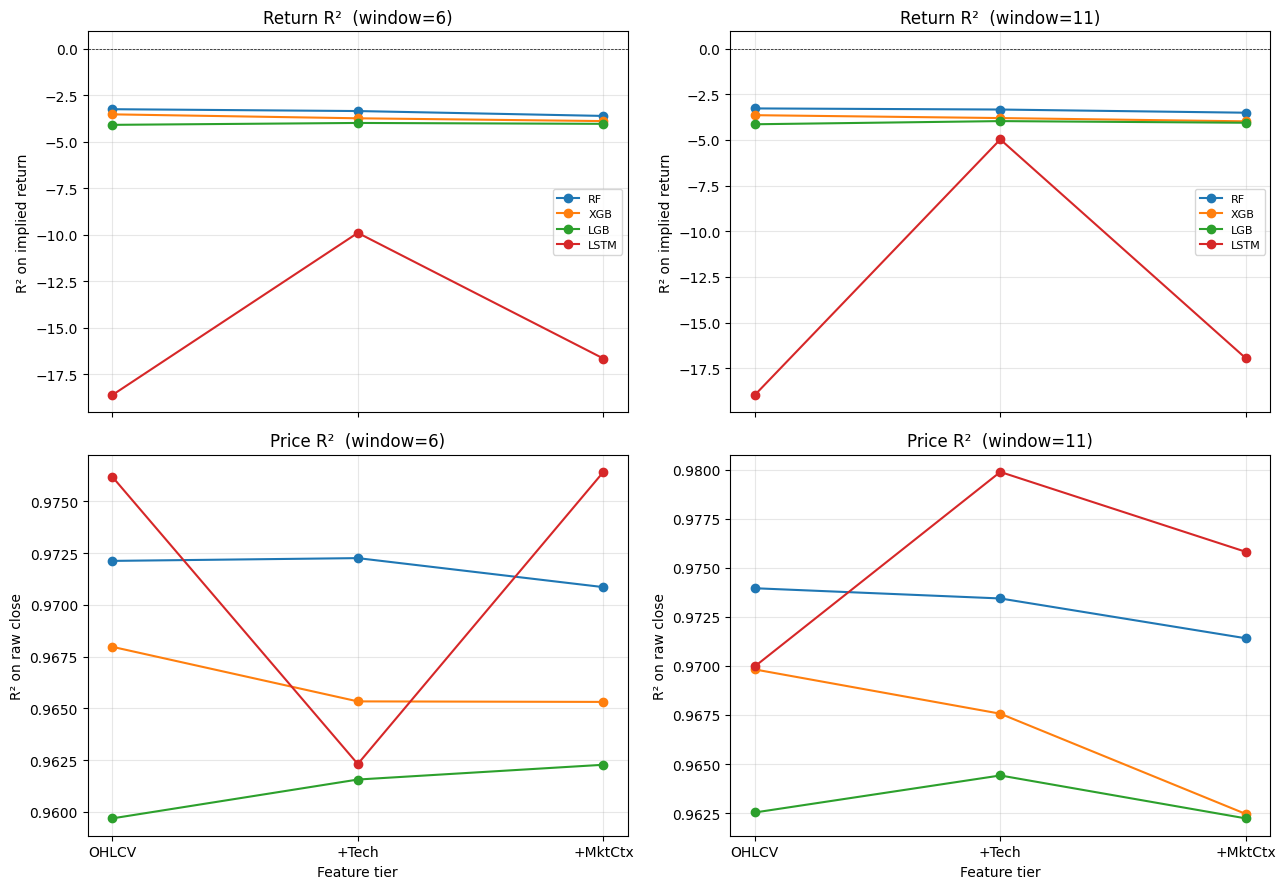

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex="col")
for col_idx, window in enumerate(WINDOWS):
    sub = summary[summary["window"] == window]
    # Row 0: return_r2
    ax = axes[0, col_idx]
    for model_name in TABULAR_MODELS + ["LSTM"]:
        rows = sub[sub["model"] == model_name].sort_values(
            "tier", key=lambda s: s.map({t: i for i, t in enumerate(TIER_ORDER)})
        )
        ax.plot(rows["tier"].values, rows["return_r2"].values, marker="o", label=model_name)
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.set_title(f"Return R²  (window={window})")
    ax.set_ylabel("R² on implied return")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

    # Row 1: price_r2
    ax = axes[1, col_idx]
    for model_name in TABULAR_MODELS + ["LSTM"]:
        rows = sub[sub["model"] == model_name].sort_values(
            "tier", key=lambda s: s.map({t: i for i, t in enumerate(TIER_ORDER)})
        )
        ax.plot(rows["tier"].values, rows["price_r2"].values, marker="o", label=model_name)
    ax.set_title(f"Price R²  (window={window})")
    ax.set_ylabel("R² on raw close")
    ax.set_xlabel("Feature tier")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "ablation_bars.png", dpi=120)
plt.show()


## 11. Predicted vs actual scatter (best config)

One point per (ticker, monday) in the test set. Includes the 45-degree line
so the per-ticker scale clusters are visible.

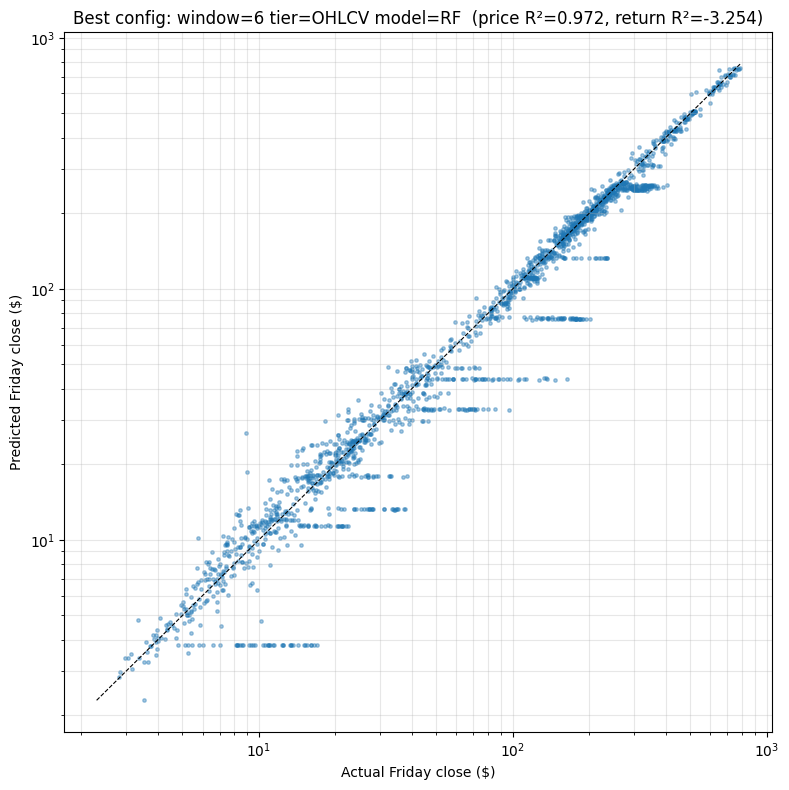

In [12]:
best_pred = preds_store[best_key]
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(test_df["friday_close"].values, best_pred, s=6, alpha=0.4)
lo = min(test_df["friday_close"].min(), best_pred.min())
hi = max(test_df["friday_close"].max(), best_pred.max())
ax.plot([lo, hi], [lo, hi], color="black", linewidth=0.8, linestyle="--")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Actual Friday close ($)")
ax.set_ylabel("Predicted Friday close ($)")
ax.set_title(
    f"Best config: window={best_key[0]} tier={best_key[1]} model={best_key[2]}  "
    f"(price R²={best_row['price_r2']:.3f}, return R²={best_row['return_r2']:.3f})"
)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig(OUT_DIR / "per_monday_scatter.png", dpi=120)
plt.show()


## 12. Save artifacts

- `ablation_summary.csv` - already written
- `predictions.parquet` - predictions from the best config, keyed on (ticker, monday, friday). This is what the frontend lightweight-charts will consume.
- `best_model.pkl` (tabular) or `best_lstm.pt` (LSTM) + `feature_scaler.pkl`


In [13]:
pred_df = test_df[["ticker", "monday_date", "friday_date", "monday_close", "friday_close"]].copy()
pred_df["pred_friday_close"] = best_pred
pred_df["actual_return"] = pred_df["friday_close"] / pred_df["monday_close"] - 1.0
pred_df["pred_return"] = pred_df["pred_friday_close"] / pred_df["monday_close"] - 1.0
pred_df["window"] = best_key[0]
pred_df["tier"] = best_key[1]
pred_df["model"] = best_key[2]
pred_df.to_parquet(OUT_DIR / "predictions.parquet", index=False)
print(f"wrote predictions: {len(pred_df):,} rows -> {OUT_DIR / 'predictions.parquet'}")

# Save scaler
joblib.dump({"scalers": scalers, "feature_cols": FEAT_COLS_ALL,
             "ohlcv_ch": OHLCV_CH, "tech_ch": TECH_CH, "mkt_ch": MKT_CH},
            OUT_DIR / "feature_scaler.pkl")
print(f"wrote scaler: {OUT_DIR / 'feature_scaler.pkl'}")

# Save best model
if best_key[2] == "LSTM":
    lstm_model = preds_store[("lstm_obj", best_key[0], best_key[1])]
    torch.save(
        {
            "state_dict": lstm_model.state_dict(),
            "in_channels": lstm_model.lstm.input_size,
            "window": best_key[0],
            "tier": best_key[1],
        },
        OUT_DIR / "best_lstm.pt",
    )
    print(f"wrote LSTM: {OUT_DIR / 'best_lstm.pt'}")
else:
    # retrain tabular on full train set and save (model objects kept during grid loop already trained)
    cols = tier_columns(best_key[1], best_key[0])
    final_model = make_tabular(best_key[2])
    final_model.fit(X_train_scaled[cols].values, y_train_scaled)
    joblib.dump(
        {
            "model": final_model,
            "cols": cols,
            "window": best_key[0],
            "tier": best_key[1],
            "model_name": best_key[2],
        },
        OUT_DIR / "best_model.pkl",
    )
    print(f"wrote tabular model: {OUT_DIR / 'best_model.pkl'}")


wrote predictions: 1,880 rows -> output\13_price_regression_ablation\predictions.parquet
wrote scaler: output\13_price_regression_ablation\feature_scaler.pkl


wrote tabular model: output\13_price_regression_ablation\best_model.pkl
